# Blocking-completion index: baseline scan vs incremental index

Compares the historical full-scan `Solver::decide` blocking path (**baseline**)
against the incremental `BlockingCompletionIndex` (**index**) on a universal
corpus of 1,000 conda-forge problems (seed 0, 60 s timeout, release builds).

CSVs are produced by `tools/solve-snapshot --mode universal`; problems are
joined on the unique `index` column. Figures are written next to this notebook
as PNGs.

In [1]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 150

BENCH = Path("/workspace/bench")
OUT = Path("/workspace/bench/figures")
OUT.mkdir(exist_ok=True)

base_path = BENCH / "uni1000-base.csv"
tip_path  = BENCH / "uni1000-index.csv"
base_label = "baseline (full scan)"
tip_label  = "incremental index"

paths  = [base_path, tip_path]
labels = [base_label, tip_label]

# Join key is the unique problem `index`; `requirements` may contain newlines.
dfs = [pl.read_csv(p).select(pl.col("index"), pl.col("duration"), pl.col("outcome")) for p in paths]
for label, p, df in zip(labels, paths, dfs):
    print(f"{label}: {df.height} problems, {df.select((pl.col('outcome')=='ok').sum()).item()} ok "
          f"({df.select(pl.col('duration').sum()).item():.1f}s total)")

baseline (full scan): 1000 problems, 711 ok (664.5s total)
incremental index: 1000 problems, 711 ok (670.4s total)


baseline (full scan): mean 0.664s  median 0.447s  p95 1.717s  max 7.275s  timeouts 0
incremental index: mean 0.670s  median 0.448s  p95 1.673s  max 6.907s  timeouts 0

mean ratio (base/index): 0.991x   median ratio: 0.996x


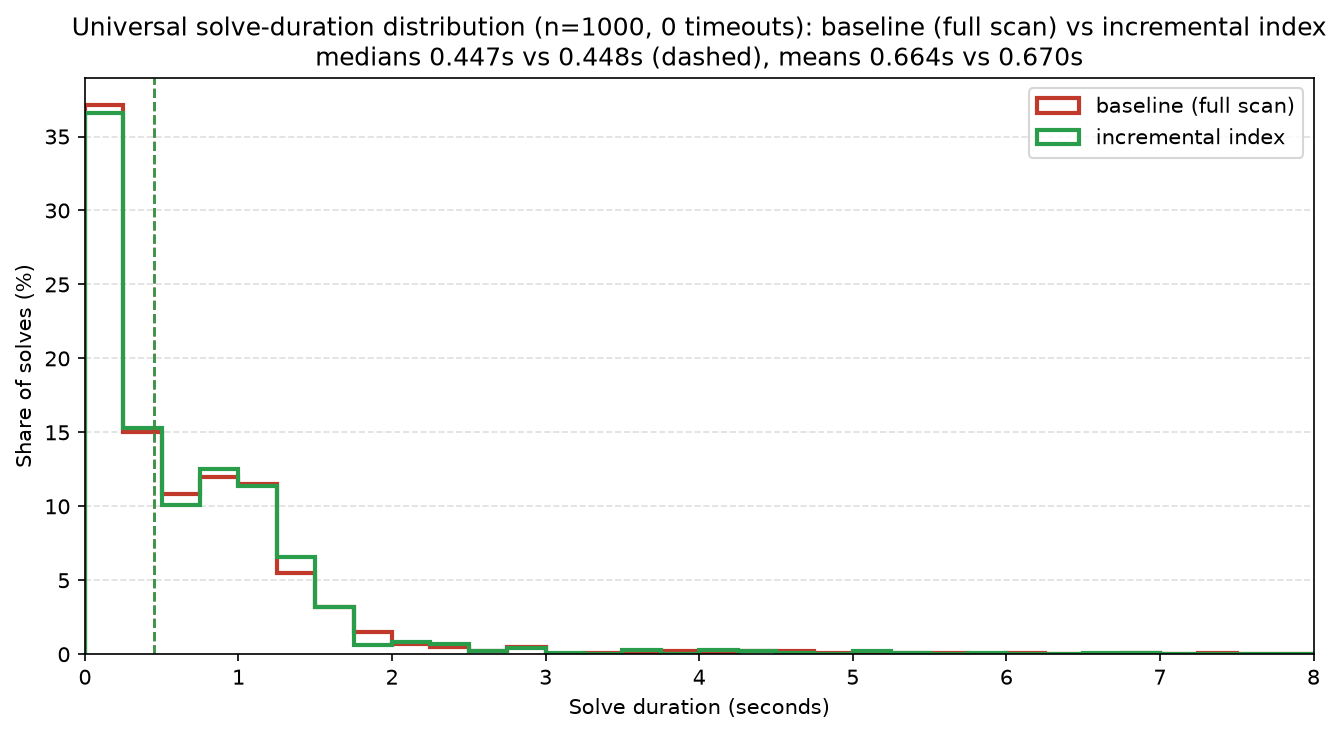

In [2]:
# --- Figure 1: solve-duration distributions, baseline vs index overlaid ---
# All solves finish well under the 60 s timeout, so cap the axis at the real
# data range and overlay both series so the (near-perfect) overlap is visible.
threshold = 60
stats = []
for label, df in zip(labels, dfs):
    v = df["duration"].to_numpy()
    stats.append(dict(label=label, mean=v.mean(), median=np.median(v),
                      p75=np.percentile(v,75), p95=np.percentile(v,95),
                      mx=v.max(), timeouts=int((v>=threshold).sum())))
    print(f"{label}: mean {v.mean():.3f}s  median {np.median(v):.3f}s  "
          f"p95 {np.percentile(v,95):.3f}s  max {v.max():.3f}s  timeouts {int((v>=threshold).sum())}")
print(f"\nmean ratio (base/index): {stats[0]['mean']/stats[1]['mean']:.3f}x   "
      f"median ratio: {stats[0]['median']/stats[1]['median']:.3f}x")

xcap = float(np.ceil(max(s['mx'] for s in stats)))   # ~8 s, well inside the timeout
bins = np.linspace(0, xcap, 33)
colors = ['#c0392b', '#2a9d4a']
fig, ax = plt.subplots(figsize=(9, 5))
for label, df, c in zip(labels, dfs, colors):
    v = np.clip(df["duration"].to_numpy(), None, xcap)
    w = np.full_like(v, 100.0 / v.size)             # y-axis in percent of solves
    ax.hist(v, bins=bins, weights=w, histtype='step', lw=2, color=c, label=label)
for s, c in zip(stats, colors):
    ax.axvline(s['median'], color=c, ls='--', lw=1.2)
ax.set_xlim(0, xcap)
ax.set_xlabel("Solve duration (seconds)")
ax.set_ylabel("Share of solves (%)")
ax.set_title(f"Universal solve-duration distribution (n={dfs[0].height}, 0 timeouts): "
             f"{base_label} vs {tip_label}\n"
             f"medians {stats[0]['median']:.3f}s vs {stats[1]['median']:.3f}s (dashed), "
             f"means {stats[0]['mean']:.3f}s vs {stats[1]['mean']:.3f}s")
ax.legend()
ax.grid(axis='y', ls='--', alpha=0.4)
plt.tight_layout()
fig.savefig(OUT / "fig1_duration_histogram.png", bbox_inches="tight")
plt.show()

per-problem diff: mean +5.91 ms, median +2.04 ms, std 66.5 ms   (faster: 425, slower: 575)


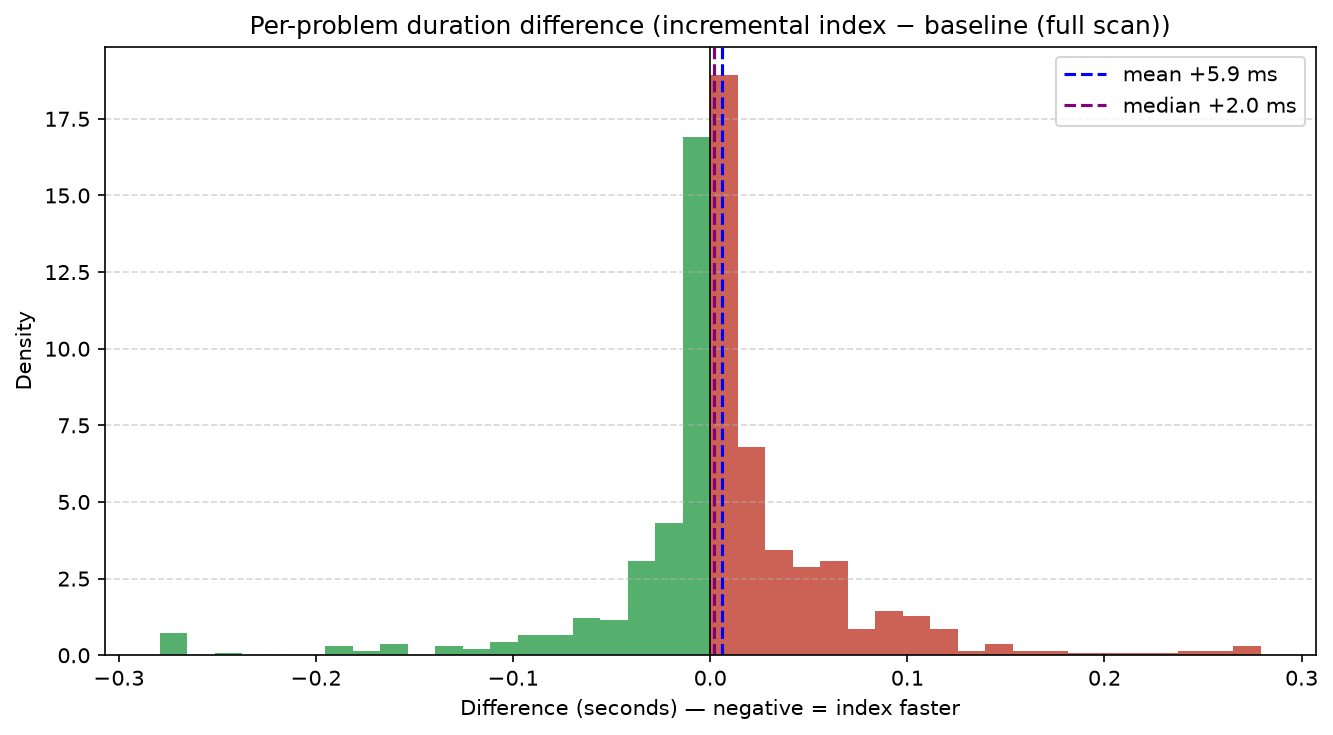

In [3]:
# --- Figure 2: per-problem difference (index - baseline); negative = index faster ---
joined = dfs[1].join(dfs[0], on="index", suffix="_base")
diff = (joined["duration"] - joined["duration_base"]).to_numpy()
mean_d, med_d = diff.mean(), np.median(diff)

fig, ax = plt.subplots(figsize=(9, 5))
lim = np.percentile(np.abs(diff), 99)  # clip axis to 99th pct so the bulk is visible
b = np.linspace(-lim, lim, 41)
n, b, patches = ax.hist(np.clip(diff, -lim, lim), bins=b, density=True, alpha=0.8)
for bar, left in zip(patches, b[:-1]):
    bar.set_facecolor('#2a9d4a' if left < 0 else '#c0392b')
ax.axvline(mean_d, color='blue', ls='--', lw=1.5, label=f"mean {mean_d*1000:+.1f} ms")
ax.axvline(med_d, color='purple', ls='--', lw=1.5, label=f"median {med_d*1000:+.1f} ms")
ax.axvline(0, color='black', lw=0.8)
ax.set_title(f"Per-problem duration difference ({tip_label} − {base_label})")
ax.set_xlabel("Difference (seconds) — negative = index faster")
ax.set_ylabel("Density")
ax.legend()
ax.grid(axis='y', ls='--', alpha=0.5)
print(f"per-problem diff: mean {mean_d*1000:+.2f} ms, median {med_d*1000:+.2f} ms, "
      f"std {diff.std()*1000:.1f} ms   (faster: {(diff<0).sum()}, slower: {(diff>0).sum()})")
plt.tight_layout()
fig.savefig(OUT / "fig2_perproblem_diff.png", bbox_inches="tight")
plt.show()

baseline scan work: {'queries': 5212, 'clause_visits': 55018, 'literal_visits': 364397, 'routed': 0, 'occ': 0}
index work:         {'queries': 4449, 'clause_visits': 51366, 'literal_visits': 345246, 'routed': 150082775, 'occ': 487483}


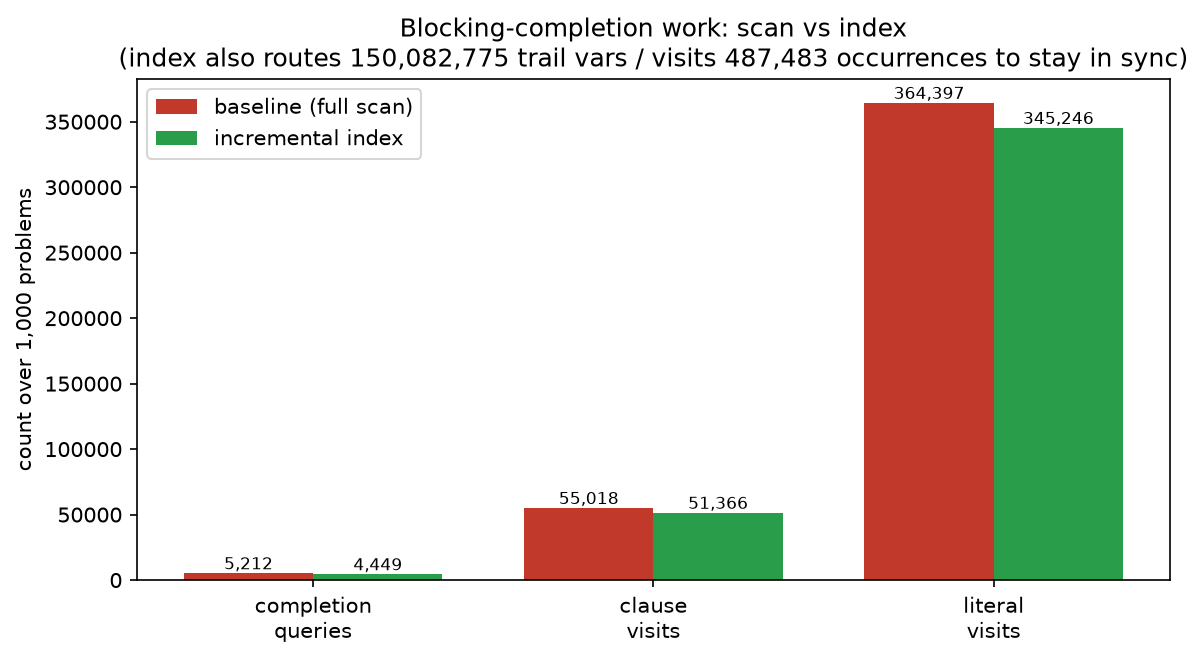

In [4]:
# --- Figure 3: blocking-completion work removed (scan literal-visits vs index recompute + routing) ---
# Parsed from the run logs' per-problem diagnostics lines.
import re
def parse_work(logpath):
    q=cv=lv=routed=occ=0
    for line in open(logpath, errors='replace'):
        if m:=re.search(r'blocking completion: (\d+) queries, (\d+) clause visits, (\d+) literal visits', line):
            q+=int(m[1]); cv+=int(m[2]); lv+=int(m[3])
        if m:=re.search(r'blocking index: \d+ registered, (\d+) routed, (\d+) occurrence visits', line):
            routed+=int(m[1]); occ+=int(m[2])
    return dict(queries=q, clause_visits=cv, literal_visits=lv, routed=routed, occ=occ)

wb = parse_work(BENCH / "uni1000-base.log")
wi = parse_work(BENCH / "uni1000-index.log")
print("baseline scan work:", wb)
print("index work:        ", wi)

fig, ax = plt.subplots(figsize=(8, 4.5))
cats = ["completion\nqueries", "clause\nvisits", "literal\nvisits"]
xb = [wb['queries'], wb['clause_visits'], wb['literal_visits']]
xi = [wi['queries'], wi['clause_visits'], wi['literal_visits']]
x = np.arange(len(cats)); w = 0.38
ax.bar(x - w/2, xb, w, label=base_label, color='#c0392b')
ax.bar(x + w/2, xi, w, label=tip_label, color='#2a9d4a')
for i,(a,b_) in enumerate(zip(xb,xi)):
    ax.text(i-w/2, a, f"{a:,}", ha='center', va='bottom', fontsize=8)
    ax.text(i+w/2, b_, f"{b_:,}", ha='center', va='bottom', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(cats)
ax.set_ylabel("count over 1,000 problems")
ax.set_title("Blocking-completion work: scan vs index\n"
             f"(index also routes {wi['routed']:,} trail vars / visits {wi['occ']:,} occurrences to stay in sync)")
ax.legend()
plt.tight_layout()
fig.savefig(OUT / "fig3_work_counters.png", bbox_inches="tight")
plt.show()